# 第 12 章 · 1D Diffusion 代码实验

[章节网页](../ch12.html)

## 运行内容

- 执行前向加噪
- 查看噪声调度
- 绘制反向轨迹

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 1D diffusion：按噪声调度逐步把 x0 混入高斯噪声。
rng = np.random.default_rng(7)
x0 = 1.0
betas = np.linspace(0.04, 0.22, 8)
alphas = 1 - betas
alpha_bars = np.cumprod(alphas)
noise = rng.normal(size=len(betas))

diff_rows = []
xs = []
for t, (alpha_bar, eps) in enumerate(zip(alpha_bars, noise), start=1):
    xt = np.sqrt(alpha_bar) * x0 + np.sqrt(1 - alpha_bar) * eps
    xs.append(xt)
    diff_rows.append({"t": t, "alpha_bar": round(alpha_bar, 3), "noise": round(eps, 3), "x_t": round(float(xt), 3)})

diff_1d_df = pd.DataFrame(diff_rows)
display(diff_1d_df)

,t,alpha_bar,noise,x_t
0,1,0.960,0.001,0.980
1,2,0.897,0.299,1.043
2,3,0.815,-0.274,0.785
3,4,0.719,-0.891,0.376
4,5,0.617,-0.455,0.504
5,6,0.513,-0.992,0.024
6,7,0.413,0.060,0.689
7,8,0.322,1.340,1.671


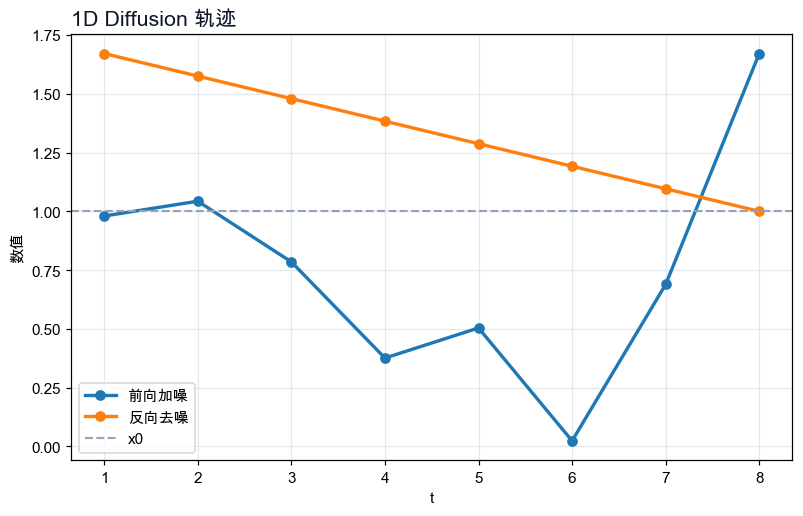

In [3]:
# 绘制前向加噪和概念性反向去噪轨迹。
reverse = np.linspace(xs[-1], x0, len(xs))
fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.plot(diff_1d_df["t"], diff_1d_df["x_t"], marker="o", linewidth=2.2, label="前向加噪")
ax.plot(diff_1d_df["t"], reverse, marker="o", linewidth=2.2, label="反向去噪")
ax.axhline(x0, color="#94a3b8", linestyle="--", linewidth=1.4, label="x0")
ax.set_title("1D Diffusion 轨迹", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
ax.set_xlabel("t")
ax.set_ylabel("数值")
ax.grid(True, color="#e2e8f0", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()